Félicitations Roland, l'environnement est opérationnel !


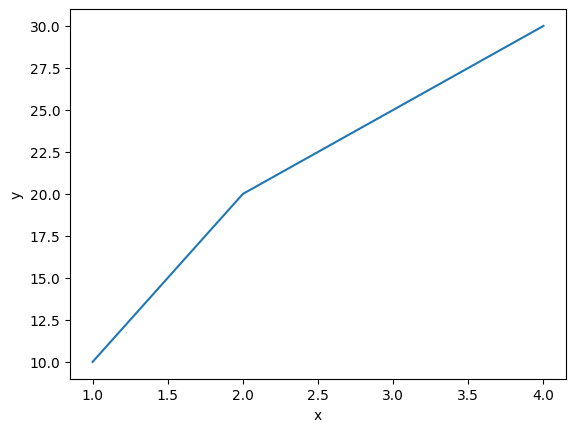

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Félicitations Roland, l'environnement est opérationnel !")

# Création d'une petite donnée pour tester le graphique
data = pd.DataFrame({'x': [1, 2, 3, 4], 'y': [10, 20, 25, 30]})
sns.lineplot(x='x', y='y', data=data)
plt.show()

In [3]:
# Simulation de logs de sécurité
logs_bruts = {
    'Heure': ['08:00', '08:05', '08:10', '08:15', '08:20'],
    'Tentatives_Login': [2, 5, 120, 3, 2], # On remarque un pic suspect à 08:10
    'Statut': ['OK', 'OK', 'Échec', 'OK', 'OK']
}

# Transformer en DataFrame
df_logs = pd.DataFrame(logs_bruts)

# Afficher les lignes où les tentatives sont supérieures à 10
alertes = df_logs[df_logs['Tentatives_Login'] > 10]
print("--- ALERTES DÉTECTÉES ---")
print(alertes)

--- ALERTES DÉTECTÉES ---
   Heure  Tentatives_Login Statut
2  08:10               120  Échec


In [4]:
# Obtenir un résumé statistique des colonnes numériques
print("--- RÉSUMÉ STATISTIQUE ---")
print(df_logs['Tentatives_Login'].describe())

# Calculer la moyenne des tentatives
moyenne = df_logs['Tentatives_Login'].mean()
print(f"\nLa moyenne des tentatives est de : {moyenne}")

--- RÉSUMÉ STATISTIQUE ---
count      5.000000
mean      26.400000
std       52.338322
min        2.000000
25%        2.000000
50%        3.000000
75%        5.000000
max      120.000000
Name: Tentatives_Login, dtype: float64

La moyenne des tentatives est de : 26.4


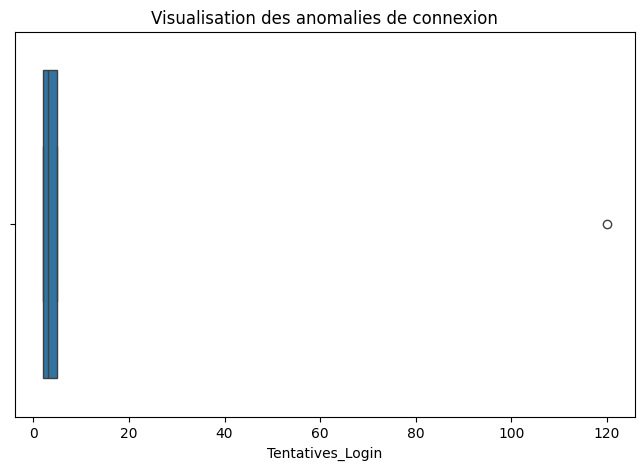

In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_logs['Tentatives_Login'])
plt.title("Visualisation des anomalies de connexion")
plt.show()

In [6]:
import pandas as pd

# Création du DataFrame avec deux colonnes
df_fichiers = pd.DataFrame({
    'NomFichier': ['rapport.txt', 'image.png', 'video.mp4', 'archive.zip', 'dataset.csv'],
    'TailleKB': [120, 450, 980, 1500, 300]
})

# Afficher uniquement le fichier qui dépasse 1000 KB
fichier_lourd = df_fichiers[df_fichiers['TailleKB'] > 1000]

print(fichier_lourd)


    NomFichier  TailleKB
3  archive.zip      1500


In [7]:
import pandas as pd
import numpy as np
import random

# Configuration de la simulation
nb_lignes = 10000
logiciels = ['HTTP', 'HTTPS', 'SSH', 'FTP', 'DNS']

# Génération de données aléatoires
data = {
    'IP_Source': [f"192.168.1.{random.randint(1, 254)}" for _ in range(nb_lignes)],
    'Protocole': [random.choice(logiciels) for _ in range(nb_lignes)],
    'Taille_Paquet_Octets': [random.randint(40, 1500) for _ in range(nb_lignes)],
    'Duree_Connexion_Sec': [random.uniform(0.1, 30.0) for _ in range(nb_lignes)]
}

# Injection d'anomalies (Attaques par déni de service simulées)
for i in range(50):
    idx = random.randint(0, nb_lignes-1)
    data['Taille_Paquet_Octets'][idx] = random.randint(5000, 10000) # Paquets énormes
    data['IP_Source'][idx] = "10.0.0.99" # IP de l'attaquant

# Création du DataFrame et sauvegarde en CSV
df_global = pd.DataFrame(data)
df_global.to_csv('trafic_reseau.csv', index=False)

print("Fichier 'trafic_reseau.csv' généré avec succès (10 000 lignes) !")

Fichier 'trafic_reseau.csv' généré avec succès (10 000 lignes) !


In [8]:
# Charger le fichier externe
df = pd.read_csv('trafic_reseau.csv')

# Afficher les 10 premières lignes pour voir à quoi ça ressemble
print("--- APERÇU DES DONNÉES ---")
print(df.head(10))

# Vérifier la santé des données (combien de lignes, types de colonnes)
print("\n--- INFOS STRUCTURELLES ---")
print(df.info())

--- APERÇU DES DONNÉES ---
       IP_Source Protocole  Taille_Paquet_Octets  Duree_Connexion_Sec
0   192.168.1.44       DNS                   403            10.790557
1   192.168.1.61     HTTPS                   817             2.979671
2  192.168.1.226     HTTPS                   370            25.297456
3   192.168.1.84       DNS                   961             1.554058
4  192.168.1.251       FTP                   781             0.523295
5  192.168.1.192      HTTP                   211            24.868959
6   192.168.1.94      HTTP                   705            26.453784
7  192.168.1.188       SSH                  1218            17.125044
8  192.168.1.204      HTTP                  1118            24.690563
9  192.168.1.219       SSH                  1215             0.862070

--- INFOS STRUCTURELLES ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                

In [9]:
# 1. Grouper par IP_Source et calculer la taille moyenne des paquets pour chaque IP
analyse_ip = df.groupby('IP_Source')['Taille_Paquet_Octets'].mean().sort_values(ascending=False)

print("--- TOP 5 DES IPS PAR TAILLE DE PAQUET MOYENNE ---")
print(analyse_ip.head(5))

# 2. Filtrer spécifiquement l'IP de l'attaquant que nous avons injecté
attaquant = df[df['IP_Source'] == '10.0.0.99']
print(f"\nNombre de connexions suspectes de l'attaquant : {len(attaquant)}")

--- TOP 5 DES IPS PAR TAILLE DE PAQUET MOYENNE ---
IP_Source
10.0.0.99        7423.840000
192.168.1.216     968.142857
192.168.1.96      954.772727
192.168.1.174     946.848485
192.168.1.119     943.906250
Name: Taille_Paquet_Octets, dtype: float64

Nombre de connexions suspectes de l'attaquant : 50


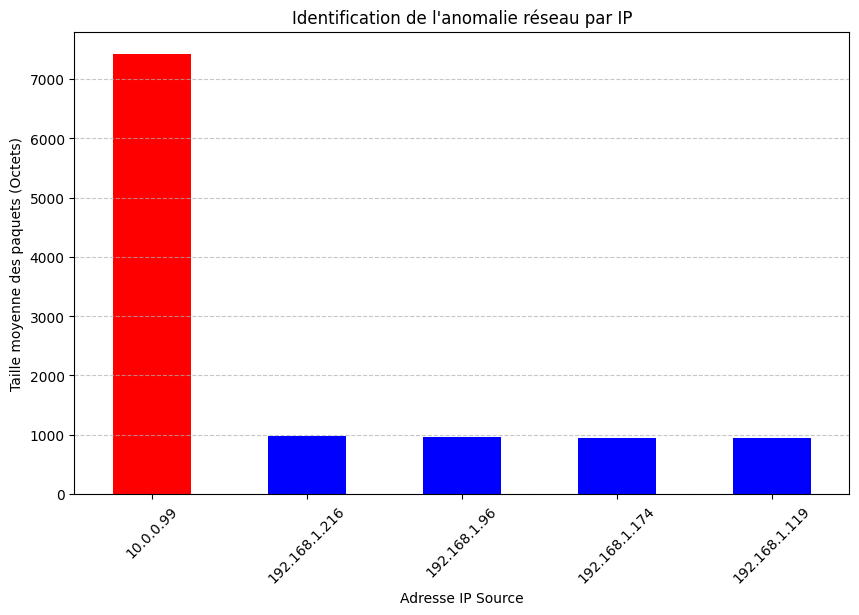

In [10]:
# Sélectionner le top 5 pour le graphique
top_5 = analyse_ip.head(5)

# Création du graphique
plt.figure(figsize=(10, 6))
top_5.plot(kind='bar', color=['red', 'blue', 'blue', 'blue', 'blue'])

plt.title("Identification de l'anomalie réseau par IP")
plt.ylabel("Taille moyenne des paquets (Octets)")
plt.xlabel("Adresse IP Source")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [11]:
# 1. Création d'un jeu de données avec des erreurs (valeurs manquantes 'None' ou 'NaN')
logs_sales = {
    'Heure': ['09:00', '09:01', '09:02', '09:03', '09:04'],
    'IP': ['192.168.1.1', None, '192.168.1.5', '192.168.1.1', None],
    'Taille_Octets': [500, 450, None, 600, 550]
}

df_sale = pd.DataFrame(logs_sales)

print("--- DONNÉES AVANT NETTOYAGE ---")
print(df_sale)

# 2. Remplacer les tailles manquantes par la moyenne (stratégie classique)
moyenne_taille = df_sale['Taille_Octets'].mean()
df_sale['Taille_Octets'] = df_sale['Taille_Octets'].fillna(moyenne_taille)

# 3. Supprimer les lignes où l'IP est inconnue (car on ne peut pas enquêter sans IP)
df_propre = df_sale.dropna(subset=['IP'])

print("\n--- DONNÉES APRÈS NETTOYAGE ---")
print(df_propre)

--- DONNÉES AVANT NETTOYAGE ---
   Heure           IP  Taille_Octets
0  09:00  192.168.1.1          500.0
1  09:01          NaN          450.0
2  09:02  192.168.1.5            NaN
3  09:03  192.168.1.1          600.0
4  09:04          NaN          550.0

--- DONNÉES APRÈS NETTOYAGE ---
   Heure           IP  Taille_Octets
0  09:00  192.168.1.1          500.0
2  09:02  192.168.1.5          525.0
3  09:03  192.168.1.1          600.0


In [12]:
# Sauvegarder le résultat propre dans un nouveau fichier CSV
df_propre.to_csv('logs_securite_nettoyes.csv', index=False)
print("Fichier prêt pour le rapport !")

Fichier prêt pour le rapport !


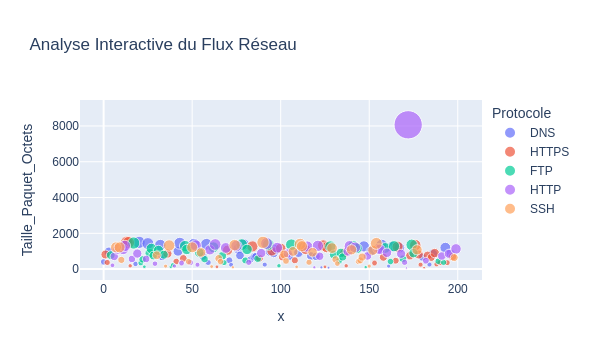

In [13]:
import plotly.express as px

# Création d'un graphique interactif sur les 200 premiers événements
fig = px.scatter(df_global.head(200), 
                 x=df_global.head(200).index, 
                 y='Taille_Paquet_Octets',
                 color='Protocole', # Une couleur différente par protocole
                 size='Taille_Paquet_Octets', # Plus le point est gros, plus le paquet est lourd
                 title='Analyse Interactive du Flux Réseau',
                 hover_data=['IP_Source', 'Protocole', 'Duree_Connexion_Sec'])

fig.show()

In [14]:
from sklearn.ensemble import IsolationForest

# 1. On prépare les données pour l'IA (elle n'aime que les chiffres)
# On va se concentrer sur la Taille et la Durée
X = df_global[['Taille_Paquet_Octets', 'Duree_Connexion_Sec']]

# 2. On crée le modèle
# 'contamination=0.01' signifie qu'on s'attend à environ 1% d'anomalies
modele_ia = IsolationForest(contamination=0.01, random_state=42)

# 3. L'IA apprend et prédit en même temps
# -1 = Anomalie détectée, 1 = Trafic normal
df_global['Score_IA'] = modele_ia.fit_predict(X)

# 4. Afficher les 5 alertes les plus graves trouvées par l'IA
alertes = df_global[df_global['Score_IA'] == -1]
print(f"L'IA a détecté {len(alertes)} anomalies critiques.")
print(alertes.head())

L'IA a détecté 100 anomalies critiques.
         IP_Source Protocole  Taille_Paquet_Octets  Duree_Connexion_Sec  \
90   192.168.1.132       SSH                  1495             1.664051   
172      10.0.0.99      HTTP                  8065            11.395332   
324  192.168.1.168       DNS                  1381            29.960588   
340   192.168.1.32     HTTPS                  1494             0.677607   
412      10.0.0.99       FTP                  5216             6.702280   

     Score_IA  
90         -1  
172        -1  
324        -1  
340        -1  
412        -1  


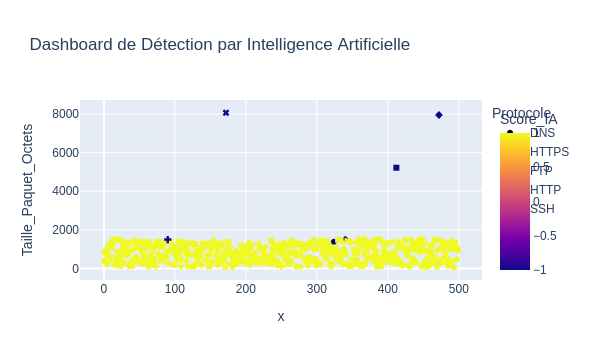

In [15]:
# Visualisation des résultats de l'IA
fig_final = px.scatter(df_global.head(500), 
                 x=df_global.head(500).index, 
                 y='Taille_Paquet_Octets',
                 color='Score_IA', # L'IA colore en jaune/bleu selon si c'est une attaque
                 symbol='Protocole',
                 title='Dashboard de Détection par Intelligence Artificielle',
                 hover_data=['IP_Source', 'Score_IA'])

fig_final.show()